# Parameter Estimation Demo: FcεRI Receptor Signaling Model

This notebook demonstrates a complete parameter estimation workflow for BioNetGen models:

1. **Setup and Imports**: Load required libraries and configure environment
2. **Model Simulation**: Load and simulate a BNGL model
3. **Synthetic Data Generation**: Create noisy observations from the model
4. **PETAb File Creation**: Build standardized data files for parameter estimation
5. **Parameter Estimation**: Use differential evolution to find optimal parameters
6. **Visualize Results**: Plot fits and compare optimization trials
7. **Identifiability Analysis**: Assess parameter identifiability using Fisher Information Matrix

The workflow is designed to be **generic** and can be adapted to any BNGL model by modifying the configuration sections.

---

## Key Features

- **Automated diagnostics**: Detects and fixes common parameter estimation issues
- **PETAb standard**: Uses industry-standard format for reproducibility
- **Identifiability analysis**: Recommends which parameters to fix based on data
- **Comprehensive visualization**: Multiple plots to assess fit quality

**Important files**:
- `PARAMETER_FIXING_GUIDE.md` - Guide for handling non-identifiable parameters
- `IDENTIFIABILITY_HELP_README.md` - Quick start guide for identifiability analysis

## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.linalg import svd
import os
import json
from datetime import datetime
from typing import List, Dict, Tuple

# Import our custom classes
from python.bngl_simulator import BNGLSimulator
from python.parameter_estimator import ParameterEstimator

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## 2. Load and Simulate the BNGL Model

First, let's load the FcεRI receptor signaling model and run a reference simulation with the "true" parameter values.

In [ ]:
# Path to the BNGL model file
bngl_file = 'fceri_starter.bngl'

# Initialize the simulator
simulator = BNGLSimulator(bngl_file)

print("Model loaded successfully!")
print(f"\nParameters ({len(simulator.parameters)}):")
for param in simulator.parameters:
    print(f"  {param:15s} = {simulator.get_parameter(param):.6e}")

print(f"\nObservables ({len(simulator.observables)}):")
for obs in simulator.observables:
    print(f"  {obs}")

Model loaded successfully!

Parameters (11):
  Lig_tot         = 6.000000e+03
  Rec_tot         = 4.000000e+02
  Lyn_tot         = 2.800000e+01
  kp1             = 1.328452e-07
  km1             = 0.000000e+00
  kp2             = 2.500000e-01
  km2             = 0.000000e+00
  kpL             = 5.000000e-02
  kmL             = 2.000000e+01
  pLb             = 3.000000e+01
  dm              = 2.000000e+01

Observables (6):
  RecDimer1
  RecDimer2
  LynFree
  LynBoundU
  BetaP1
  BetaP2


## 3. Generate Synthetic Data

### 3.1 Configuration: Experimental Design

**MODIFY THIS SECTION** to change your experimental design:
- Which observables to measure
- What experimental conditions to test
- Which timepoints to sample

### 3.1 Configuration: Experimental Design

**MODIFY THIS SECTION** to change your experimental design:
- Which observables to measure
- What experimental conditions to test
- Which timepoints to sample

In [ ]:
# =============================================================================
# EXPERIMENTAL DESIGN CONFIGURATION
# =============================================================================

# Define "true" parameter values (these will be used to generate synthetic data)
# In a real scenario, these are unknown and we're trying to estimate them
true_params = {
    'kp1': 1.32845238e-7,  # Ligand-receptor binding
    'kp2': 2.5e-1,         # Receptor aggregation
    'kpL': 5e-2,           # Lyn binding
    'kmL': 20,             # Lyn unbinding
    'pLb': 30,             # Trans-phosphorylation rate
    'dm': 20,              # Dephosphorylation rate
}

# Define experimental conditions (different initial concentrations)
# Each condition is a dictionary of parameter overrides
experimental_conditions = [
    {
        'conditionId': 'LigHigh',
        'conditionName': 'High Ligand',
        'Lig_tot': 6.0e3,  # High ligand concentration
    },
    {
        'conditionId': 'LigLow',
        'conditionName': 'Low Ligand',
        'Lig_tot': 1.0e3,  # Low ligand concentration
    },
    {
        'conditionId': 'LigMed',
        'conditionName': 'Medium Ligand',
        'Lig_tot': 3.0e3,  # Medium ligand concentration
    },
]

# Define which observables to "measure"
# These are the model observables we'll treat as experimental data
measured_observables = ['BetaP2'] #['RecDimer2', 'LynBoundU', 'BetaP2']

# Define sampling timepoints (in seconds)
# Using irregular sampling to mimic real experiments
measurement_times = [0, 30, 60, 120, 180, 300, 600, 1200]

# Noise model parameters
# We'll use proportional Gaussian noise: noise_std = relative_error * measurement
# This is standard for biological data where measurement error scales with signal
relative_error = 0.10  # 10% relative error (coefficient of variation)

print(f"Experimental design:")
print(f"  Conditions: {len(experimental_conditions)}")
print(f"  Observables: {len(measured_observables)}")
print(f"  Timepoints: {len(measurement_times)}")
print(f"  Total measurements: {len(experimental_conditions) * len(measured_observables) * len(measurement_times)}")
print(f"  Noise model: {relative_error*100:.0f}% relative error (proportional Gaussian)")

Experimental design:
  Conditions: 3
  Observables: 1
  Timepoints: 8
  Total measurements: 24
  Noise model: 10% relative error (proportional Gaussian)


### 3.2 Noise Model Options

**Common noise models for biological data:**

1. **Proportional (Relative) Noise** *(used here)*:
   - `noise_std = relative_error * |measurement|`
   - Appropriate when measurement uncertainty scales with signal magnitude
   - Common in biochemical assays (e.g., Western blots, flow cytometry)
   
2. **Constant Absolute Noise**:
   - `noise_std = constant`
   - Appropriate when measurement error is independent of signal
   - Common in counting experiments
   
3. **Mixed Noise**:
   - `noise_std = sqrt((relative_error * measurement)^2 + constant^2)`
   - Combines both error sources
   - Most realistic but adds complexity

**To change noise model**, modify the `generate_noisy_measurement` function below.

In [ ]:
def generate_noisy_measurement(true_value: float, 
                              relative_error: float = 0.10,
                              min_noise: float = 1e-3) -> Tuple[float, float]:
    """
    Generate a noisy measurement with proportional Gaussian noise.
    
    Args:
        true_value: True (noiseless) value
        relative_error: Relative error (coefficient of variation)
        min_noise: Minimum absolute noise level (prevents division by zero)
    
    Returns:
        Tuple of (noisy_measurement, noise_std)
    """
    # Proportional noise: noise scales with signal magnitude
    noise_std = max(relative_error * abs(true_value), min_noise)
    
    # Generate noisy measurement
    noisy_value = true_value + np.random.normal(0, noise_std)
    
    # Optional: ensure non-negative (uncomment if needed)
    # noisy_value = max(0, noisy_value)
    
    return noisy_value, noise_std

### 3.3 Generate Synthetic Data

In [ ]:
# Store all synthetic measurements
synthetic_data = []

# Set simulator to true parameter values
for param_name, param_value in true_params.items():
    simulator.set_parameter(param_name, param_value)

# Generate data for each experimental condition
for condition in experimental_conditions:
    cond_id = condition['conditionId']
    print(f"\nGenerating data for condition: {cond_id}")
    
    # Extract condition-specific parameters (initial concentrations, etc.)
    cond_params = {k: v for k, v in condition.items() 
                   if k not in ['conditionId', 'conditionName']}
    
    # Simulate with condition-specific parameters
    t_end = max(measurement_times)
    n_steps = 200
    result = simulator.simulate(t_end=t_end, n_steps=n_steps, 
                                reference_values=cond_params, reset=True)
    
    # Extract measurements at specified timepoints
    for obs_name in measured_observables:
        for meas_time in measurement_times:
            # Find closest simulation timepoint
            time_idx = np.argmin(np.abs(result['time'] - meas_time))
            true_value = result[obs_name][time_idx]
            
            # Generate noisy measurement
            noisy_value, noise_std = generate_noisy_measurement(
                true_value, relative_error=relative_error
            )
            
            # Store measurement
            synthetic_data.append({
                'observableId': obs_name,
                'simulationConditionId': cond_id,
                'measurement': noisy_value,
                'time': meas_time,
                'observableParameters': f"{noise_std};3",  # Format: "SD;N" for SEM calculation
                'noiseParameters': noise_std,
                'datasetId': 'synthetic',
                'replicateId': 1,
            })

print(f"\nGenerated {len(synthetic_data)} synthetic measurements")

# Convert to DataFrame
measurements_df = pd.DataFrame(synthetic_data)
print("\nFirst few measurements:")
print(measurements_df.head(10))


Generating data for condition: LigHigh

Generating data for condition: LigLow

Generating data for condition: LigMed

Generated 24 synthetic measurements

First few measurements:
  observableId simulationConditionId  measurement  time  \
0       BetaP2               LigHigh     0.000497     0   
1       BetaP2               LigHigh     1.006058    30   
2       BetaP2               LigHigh     2.074134    60   
3       BetaP2               LigHigh     4.097964   120   
4       BetaP2               LigHigh     4.770302   180   
5       BetaP2               LigHigh     6.729970   300   
6       BetaP2               LigHigh    11.038288   600   
7       BetaP2               LigHigh    11.867822  1200   
8       BetaP2                LigLow    -0.000469     0   
9       BetaP2                LigLow     0.186301    30   

     observableParameters  noiseParameters  datasetId  replicateId  
0                 0.001;3         0.001000  synthetic            1  
1   0.10201635486874408;3       

### 3.4 Visualize Synthetic Data

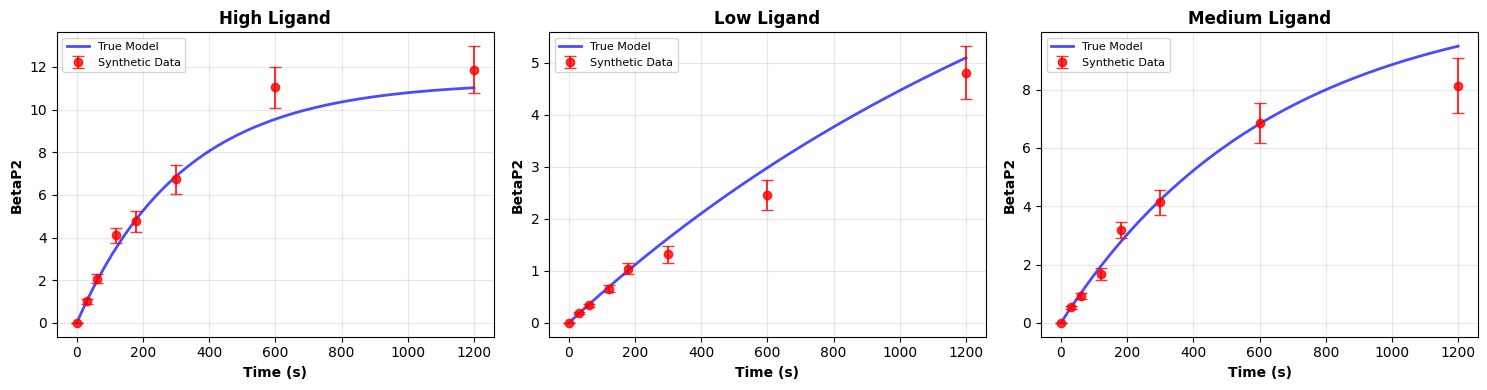

Saved figure: synthetic_data.png


In [ ]:
# Plot synthetic data vs true trajectories
n_conditions = len(experimental_conditions)
n_obs = len(measured_observables)

fig, axes = plt.subplots(n_obs, n_conditions, 
                        figsize=(5*n_conditions, 4*n_obs), squeeze=False)

for obs_idx, obs_name in enumerate(measured_observables):
    for cond_idx, condition in enumerate(experimental_conditions):
        cond_id = condition['conditionId']
        ax = axes[obs_idx, cond_idx]
        
        # Get condition-specific parameters
        cond_params = {k: v for k, v in condition.items() 
                      if k not in ['conditionId', 'conditionName']}
        
        # Simulate true trajectory (high resolution)
        result = simulator.simulate(t_end=max(measurement_times), n_steps=200,
                                   reference_values=cond_params, reset=True)
        
        # Plot true trajectory
        ax.plot(result['time'], result[obs_name], 'b-', linewidth=2, 
               label='True Model', alpha=0.7)
        
        # Plot noisy measurements
        cond_data = measurements_df[
            (measurements_df['simulationConditionId'] == cond_id) &
            (measurements_df['observableId'] == obs_name)
        ]
        
        # Extract noise levels
        noise_stds = cond_data['noiseParameters'].values
        
        ax.errorbar(cond_data['time'], cond_data['measurement'], 
                   yerr=noise_stds, fmt='ro', markersize=6, 
                   capsize=4, label='Synthetic Data', alpha=0.8)
        
        ax.set_xlabel('Time (s)', fontweight='bold')
        ax.set_ylabel(obs_name, fontweight='bold')
        ax.set_title(f"{condition['conditionName']}", fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_data.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved figure: synthetic_data.png")

## 4. Create PETAb Files

PETAb (Parameter Estimation Tabular data) is a standardized format for specifying parameter estimation problems. It consists of several TSV files:

1. **measurements.tsv**: Experimental measurements
2. **conditions.tsv**: Experimental conditions (different initial states)
3. **observables.tsv**: Mapping between model outputs and measurements
4. **parameters.tsv**: Parameter bounds and prior information

### 4.1 Configuration: Parameters to Estimate

**MODIFY THIS SECTION** to change which parameters to estimate:

In [ ]:
# =============================================================================
# PARAMETER ESTIMATION CONFIGURATION
# =============================================================================

# Define which parameters to estimate
# These should be model parameters (kinetic rates, initial concentrations, etc.)
parameters_to_estimate = [
    {
        'parameterId': 'kp1',
        'parameterName': 'Ligand-receptor binding rate',
        'nominalValue': 1e-7,        # Initial guess
        'lowerBound': 1e-9,          # Lower bound for optimization
        'upperBound': 1e-5,          # Upper bound for optimization
        'parameterScale': 'log10',   # Search in log-space
        'estimate': 1,               # 1 = estimate, 0 = fixed
    },
    {
        'parameterId': 'kp2',
        'parameterName': 'Receptor aggregation rate',
        'nominalValue': 0.1,
        'lowerBound': 1e-3,
        'upperBound': 1.0,
        'parameterScale': 'log10',
        'estimate': 0,
    },
    {
        'parameterId': 'kpL',
        'parameterName': 'Lyn binding rate',
        'nominalValue': 0.01,
        'lowerBound': 1e-4,
        'upperBound': 1.0,
        'parameterScale': 'log10',
        'estimate': 1,
    },
    {
        'parameterId': 'kmL',
        'parameterName': 'Lyn unbinding rate',
        'nominalValue': 10,
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 0,
    },
    {
        'parameterId': 'pLb',
        'parameterName': 'Trans-phosphorylation rate',
        'nominalValue': 20,
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 0,
    },
    {
        'parameterId': 'dm',
        'parameterName': 'Dephosphorylation rate',
        'nominalValue': 10,
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 1,
    },
]

# Add noise parameters (one per observable)
# These represent measurement uncertainty and are typically estimated
for obs_name in measured_observables:
    parameters_to_estimate.append({
        'parameterId': f'sigma_{obs_name}',
        'parameterName': f'Noise parameter for {obs_name}',
        'nominalValue': 10.0,        # Initial guess for noise level
        'lowerBound': 0.1,
        'upperBound': 100.0,
        'parameterScale': 'log10',
        'estimate': 1,               # Set to 0 if noise is known
    })

n_fixed = len([p for p in parameters_to_estimate if p['estimate'] == 0])
print(f"  Number of fixed parameters: {n_fixed}")
n_estimate=len([p for p in parameters_to_estimate if p['estimate'] == 1])
# Print the fixed parameter names
print(f"  Fixed parameters: {[p['parameterId'] for p in parameters_to_estimate if p['estimate'] == 0]}")
print(f"  Number of parameters to estimate: {n_estimate}")
# Print the parameter names to estimate
print(f"  Parameters to estimate: {[p['parameterId'] for p in parameters_to_estimate if p['estimate'] == 1]}")


  Number of fixed parameters: 3
  Fixed parameters: ['kp2', 'kmL', 'pLb']
  Number of parameters to estimate: 4
  Parameters to estimate: ['kp1', 'kpL', 'dm', 'sigma_BetaP2']


### 4.1 Configuration: Parameters to Estimate

**MODIFY THIS SECTION** to change which parameters to estimate:

### 4.2 Configuration: Observable Formulas

**MODIFY THIS SECTION** to change how observables are mapped to data:

Observable formulas can include:
- Direct mapping: `"RecDimer2"` (use model observable directly)
- Scaling: `"scale_RecDimer2 * RecDimer2"` (add scaling parameter)
- Offset: `"RecDimer2 + baseline_RecDimer2"` (add baseline)
- Both: `"scale_RecDimer2 * RecDimer2 + baseline_RecDimer2"`
- Math: `"log10(RecDimer2 + 1)"` (logarithmic transformation)

In [ ]:
# =============================================================================
# OBSERVABLE CONFIGURATION
# =============================================================================

# Define observable formulas (how measurements relate to model outputs)
observables_config = []

for obs_name in measured_observables:
    observables_config.append({
        'observableId': obs_name,
        'observableName': obs_name,
        'observableFormula': obs_name,           # Direct mapping (no transformation)
        'noiseFormula': f'sigma_{obs_name}',     # Noise parameter
        'observableTransformation': 'lin',       # lin or log10
        'noiseDistribution': 'normal',           # normal or laplace
    })

print("Observable configurations:")
for obs in observables_config:
    print(f"  {obs['observableId']}: {obs['observableFormula']} (noise: {obs['noiseFormula']})")

Observable configurations:
  BetaP2: BetaP2 (noise: sigma_BetaP2)


### 4.3 Create PETAb DataFrames

In [ ]:
# Create conditions DataFrame
conditions_df = pd.DataFrame(experimental_conditions)
print("Conditions table:")
print(conditions_df)
print()

# Create observables DataFrame
observables_df = pd.DataFrame(observables_config)
print("Observables table:")
print(observables_df)
print()

# Create parameters DataFrame
parameters_df = pd.DataFrame(parameters_to_estimate)
print("Parameters table:")
print(parameters_df)
print()

# Measurements already created above
print("Measurements table (first 10 rows):")
print(measurements_df.head(10))

Conditions table:
  conditionId  conditionName  Lig_tot
0     LigHigh    High Ligand   6000.0
1      LigLow     Low Ligand   1000.0
2      LigMed  Medium Ligand   3000.0

Observables table:
  observableId observableName observableFormula  noiseFormula  \
0       BetaP2         BetaP2            BetaP2  sigma_BetaP2   

  observableTransformation noiseDistribution  
0                      lin            normal  

Parameters table:
    parameterId                 parameterName  nominalValue    lowerBound  \
0           kp1  Ligand-receptor binding rate  1.000000e-07  1.000000e-09   
1           kp2     Receptor aggregation rate  1.000000e-01  1.000000e-03   
2           kpL              Lyn binding rate  1.000000e-02  1.000000e-04   
3           kmL            Lyn unbinding rate  1.000000e+01  1.000000e+00   
4           pLb    Trans-phosphorylation rate  2.000000e+01  1.000000e+00   
5            dm        Dephosphorylation rate  1.000000e+01  1.000000e+00   
6  sigma_BetaP2    Noise pa

### 4.4 Save PETAb Files

In [ ]:
# Create output directory for PETAb files
petab_dir = 'petab_files'
os.makedirs(petab_dir, exist_ok=True)

# Save all PETAb tables
conditions_df.to_csv(f'{petab_dir}/conditions.tsv', sep='\t', index=False)
measurements_df.to_csv(f'{petab_dir}/measurements.tsv', sep='\t', index=False)
observables_df.to_csv(f'{petab_dir}/observables.tsv', sep='\t', index=False)
parameters_df.to_csv(f'{petab_dir}/parameters.tsv', sep='\t', index=False)

print(f"PETAb files saved to '{petab_dir}/' directory:")
print(f"  - conditions.tsv")
print(f"  - measurements.tsv")
print(f"  - observables.tsv")
print(f"  - parameters.tsv")

PETAb files saved to 'petab_files/' directory:
  - conditions.tsv
  - measurements.tsv
  - observables.tsv
  - parameters.tsv


## 5. Parameter Estimation with Differential Evolution

### 5.1 Initialize Parameter Estimator

In [ ]:
# Initialize the parameter estimator
estimator = ParameterEstimator(
    bngl_file=bngl_file,
    conditions_df=conditions_df,
    measurements_df=measurements_df,
    observables_df=observables_df,
    parameters_df=parameters_df,
)

print(f"\nEstimator initialized with:")
print(f"  Estimable parameters: {len(estimator.estimable_params)}")
print(f"  Parameters: {estimator.estimable_params}")

Initialized estimator with 4 estimable parameters
Timepoints: [   0   30   60  120  180  300  600 1200]

Estimator initialized with:
  Estimable parameters: 4
  Parameters: ['kp1', 'kpL', 'dm', 'sigma_BetaP2']


### 5.1 Initialize Parameter Estimator

### 5.1.1 Debug Fixed Parameter Issues

**Critical Issue:** When parameters are fixed (`estimate=0`), the estimator uses their `nominalValue`.

If these don't match the true values, testing at "true parameters" gives WRONG results!

This cell:
1. Diagnoses what values the estimator is actually using
2. Shows you exactly what's wrong
3. Provides an immediate fix (no need to re-run everything)

In [ ]:
from python.debug_fixed_params import diagnose_fixed_parameter_issue, quick_fix_estimator_nominals

# Diagnose the issue
diagnosis = diagnose_fixed_parameter_issue(
    estimator=estimator,
    parameters_to_estimate=parameters_to_estimate,
    true_params=true_params,
    verbose=True
)

# If issues found, apply quick fix
if len(diagnosis['issues']) > 0:
    print("\n" + "="*80)
    print("APPLYING QUICK FIX")
    print("="*80)
    
    n_fixed = quick_fix_estimator_nominals(
        estimator=estimator,
        parameters_to_estimate=parameters_to_estimate,
        true_params=true_params
    )
    
    if n_fixed > 0:
        print("\n" + "="*80)
        print("FIX APPLIED SUCCESSFULLY!")
        print("="*80)
        print("\nThe estimator now has correct nominal values.")
        print("You can proceed to Section 5.2 to test NLLH.")
        print("\nNOTE: This is a temporary fix. For permanent fix:")
        print("  1. Go to Section 4.1")
        print("  2. Update nominalValue for fixed parameters")
        print("  3. Re-run from 4.3 onwards")
else:
    print("\n✓ No issues! Estimator is correctly configured.")

# Show the correct way to construct true_param_dict
print("\n" + "="*80)
print("FOR FUTURE REFERENCE")
print("="*80)
print("\nWhen testing at true parameters, use:")
print("\ntrue_param_dict_correct = {")
for k, v in diagnosis['true_param_dict_correct'].items():
    print(f"    '{k}': {v:.6e},")
print("}")
print("\ntrue_vector = estimator.params_to_vector(true_param_dict_correct)")
print("nllh = estimator.compute_nllh(true_vector)")

FIXED PARAMETER DIAGNOSTIC

Parameter counts:
  Fixed:     3
  Estimated: 3
  Total:     6

Estimator's estimable_params:
  ['kp1', 'kpL', 'dm', 'sigma_BetaP2']

Fixed parameters in detail:
  Parameter       In Config       In Estimator    True Value      Match?    
  ---------------------------------------------------------------------------
  kp2             1.000000e-01    0.1             0.25            ✗ (60.0%) 
  kmL             1.000000e+01    10.0            20              ✗ (50.0%) 
  pLb             2.000000e+01    20.0            30              ✗ (33.3%) 

How to construct true_param_dict for testing:
  Option 1: Include ALL parameters (both fixed and estimated)
  Option 2: Include only ESTIMATED parameters
  → Estimator will add fixed params at nominal values automatically

Correct true_param_dict (estimated params only):
  kp1: 1.328452e-07
  kpL: 5.000000e-02
  dm: 2.000000e+01

TESTING NLLH WITH DIFFERENT CONFIGURATIONS

Test 1: true_param_dict with only ESTIMATED par

### 5.2 Test Objective Function

Let's test the objective function (negative log-likelihood) at the true parameter values and at the initial guess.

In [ ]:
# Convert true parameters to vector
true_param_dict = {}
for param in parameters_to_estimate:
    param_id = param['parameterId']
    if param_id in true_params:
        true_param_dict[param_id] = true_params[param_id]
    elif param_id.startswith('sigma_'):
        # For noise parameters, use the actual noise level from data generation
        obs_name = param_id.replace('sigma_', '')
        # Average noise level for this observable
        avg_noise = measurements_df[
            measurements_df['observableId'] == obs_name
        ]['noiseParameters'].mean()
        true_param_dict[param_id] = avg_noise
    else:
        true_param_dict[param_id] = param['nominalValue']

true_vector = estimator.params_to_vector(true_param_dict)

# Initial guess (from parameters table)
initial_guess = np.array([p['nominalValue'] for p in parameters_to_estimate])
initial_vector = estimator.params_to_vector(
    {p['parameterId']: p['nominalValue'] for p in parameters_to_estimate}
)

# Evaluate objective function
print("Testing objective function...")
nllh_true = estimator.compute_nllh(true_vector, verbose=True)
print(f"\nNLLH at TRUE parameters: {nllh_true:.4f}")

nllh_initial = estimator.compute_nllh(initial_vector, verbose=True)
print(f"\nNLLH at INITIAL guess: {nllh_initial:.4f}")

print(f"\nDifference: {nllh_initial - nllh_true:.4f}")
print(f"(Lower is better - optimization will try to minimize NLLH)")

Testing objective function...
NLLH = -9.8626 (24 datapoints)

NLLH at TRUE parameters: -9.8626
NLLH = 802.4525 (24 datapoints)

NLLH at INITIAL guess: 802.4525

Difference: 812.3151
(Lower is better - optimization will try to minimize NLLH)


### 5.3 Configuration: Optimization Settings

**MODIFY THIS SECTION** to change optimization behavior:

In [ ]:
# =============================================================================
# OPTIMIZATION CONFIGURATION
# =============================================================================

# Number of independent optimization trials
# More trials increase chance of finding global optimum but take longer
n_trials = 1 # Set this higher (e.g., 5 or 10) for more robust optimization

# Differential evolution parameters
de_config = {
    'strategy': 'best1bin',      # DE strategy (best1bin, rand1bin, etc.)
    'maxiter': 100,              # Maximum number of generations
    'popsize': 15,               # Population size (multiplier of parameter count)
    'tol': 0.01,                 # Relative tolerance for convergence
    'mutation': (0.5, 1.5),      # Mutation constant (range)
    'recombination': 0.7,        # Crossover probability
    'polish': True,              # Use L-BFGS-B to polish the best solution
    'workers': 1,                # Number of parallel workers (set to -1 for all cores)
    'updating': 'deferred',      # Update strategy (immediate or deferred)
}

print(f"Optimization configuration:")
print(f"  Trials: {n_trials}")
print(f"  Max iterations: {de_config['maxiter']}")
print(f"  Population size: {de_config['popsize']} × {len(estimator.estimable_params)} = {de_config['popsize'] * len(estimator.estimable_params)}")
print(f"  Total function evaluations (approx): {de_config['maxiter'] * de_config['popsize'] * len(estimator.estimable_params) * n_trials}")

Optimization configuration:
  Trials: 1
  Max iterations: 100
  Population size: 15 × 4 = 60
  Total function evaluations (approx): 6000


### 5.4 Run Multi-Trial Optimization

We'll run multiple independent optimization trials and save the best result from each.

In [ ]:
# Get parameter bounds
bounds_lower, bounds_upper = estimator.get_bounds()
bounds = list(zip(bounds_lower, bounds_upper))

# Store results from all trials
trial_results = []

# Run multiple trials
for trial_idx in range(n_trials):
    print(f"\n{'='*80}")
    print(f"TRIAL {trial_idx + 1}/{n_trials}")
    print(f"{'='*80}")
    
    # Run differential evolution
    result = differential_evolution(
        func=estimator.compute_nllh,
        bounds=bounds,
        seed=42 + trial_idx,  # Different seed for each trial
        **de_config,
        disp=True,
    )
    
    # Store result
    trial_result = {
        'trial_idx': trial_idx,
        'success': result.success,
        'nllh': result.fun,
        'nfev': result.nfev,
        'nit': result.nit,
        'param_vector': result.x,
        'param_dict': estimator.vector_to_params(result.x),
        'message': result.message,
    }
    trial_results.append(trial_result)
    
    print(f"\nTrial {trial_idx + 1} completed:")
    print(f"  Success: {result.success}")
    print(f"  NLLH: {result.fun:.4f}")
    print(f"  Function evaluations: {result.nfev}")
    print(f"  Iterations: {result.nit}")
    print(f"  Message: {result.message}")

print(f"\n{'='*80}")
print("ALL TRIALS COMPLETED")
print(f"{'='*80}")


TRIAL 1/1
differential_evolution step 1: f(x)= 109.23643591461072
differential_evolution step 2: f(x)= 109.23643591461072
differential_evolution step 3: f(x)= 17.8859078665812
differential_evolution step 4: f(x)= 17.8859078665812
differential_evolution step 5: f(x)= 1.2319969118885434
differential_evolution step 6: f(x)= 0.40044178347643244
differential_evolution step 7: f(x)= 0.40044178347643244
differential_evolution step 8: f(x)= 0.40044178347643244
differential_evolution step 9: f(x)= 0.40044178347643244
differential_evolution step 10: f(x)= 0.40044178347643244
differential_evolution step 11: f(x)= 0.02509992659417104
differential_evolution step 12: f(x)= -1.0148132010010218
differential_evolution step 13: f(x)= -4.147894493155839
differential_evolution step 14: f(x)= -4.147894493155839
differential_evolution step 15: f(x)= -5.04478060729733
differential_evolution step 16: f(x)= -5.754984880212014
differential_evolution step 17: f(x)= -10.081502056034099
differential_evolution ste

### 5.5 Analyze Trial Results

In [ ]:
# Find best trial
best_trial_idx = np.argmin([r['nllh'] for r in trial_results])
best_result = trial_results[best_trial_idx]

print(f"Summary of all trials:")
print(f"\n{'Trial':<8} {'NLLH':<12} {'Success':<10} {'NFev':<10} {'NIt':<10}")
print(f"{'-'*60}")
for r in trial_results:
    marker = ' *** BEST' if r['trial_idx'] == best_trial_idx else ''
    print(f"{r['trial_idx']+1:<8} {r['nllh']:<12.4f} {str(r['success']):<10} {r['nfev']:<10} {r['nit']:<10}{marker}")

print(f"\n\nBest result from trial {best_trial_idx + 1}:")
print(f"  NLLH: {best_result['nllh']:.4f}")
print(f"  Success: {best_result['success']}")
print(f"\nEstimated parameters:")
print(f"\n{'Parameter':<20} {'True':<15} {'Estimated':<15} {'Rel. Error':<15}")
print(f"{'-'*65}")

for param_id in estimator.estimable_params:
    est_value = best_result['param_dict'][param_id]
    
    if param_id in true_param_dict:
        true_value = true_param_dict[param_id]
        rel_error = abs(est_value - true_value) / true_value * 100
        print(f"{param_id:<20} {true_value:<15.6e} {est_value:<15.6e} {rel_error:<15.2f}%")
    else:
        print(f"{param_id:<20} {'N/A':<15} {est_value:<15.6e} {'N/A':<15}")

### 5.6 Save Results

In [ ]:
# Create results directory
results_dir = 'estimation_results'
os.makedirs(results_dir, exist_ok=True)

# Save all trial results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_file = f'{results_dir}/trial_results_{timestamp}.json'

# Prepare results for JSON serialization
json_results = []
for r in trial_results:
    json_result = {
        'trial_idx': r['trial_idx'],
        'success': r['success'],
        'nllh': float(r['nllh']),
        'nfev': int(r['nfev']),
        'nit': int(r['nit']),
        'param_vector': r['param_vector'].tolist(),
        'param_dict': {k: float(v) for k, v in r['param_dict'].items()},
        'message': r['message'],
    }
    json_results.append(json_result)

with open(results_file, 'w') as f:
    json.dump(json_results, f, indent=2)

print(f"Trial results saved to: {results_file}")

# Save best parameters to CSV
best_params_df = pd.DataFrame([
    {
        'parameterId': param_id,
        'estimated': best_result['param_dict'][param_id],
        'true': true_param_dict.get(param_id, np.nan),
    }
    for param_id in estimator.estimable_params
])
best_params_df['rel_error'] = np.abs(
    (best_params_df['estimated'] - best_params_df['true']) / best_params_df['true'] * 100
)

best_params_file = f'{results_dir}/best_parameters_{timestamp}.csv'
best_params_df.to_csv(best_params_file, index=False)
print(f"Best parameters saved to: {best_params_file}")

## 6. Visualize Results

### 6.1 Plot Best Fit vs Data

### 6.1 Plot Best Fit vs Data

In [ ]:
# Plot the best fit
estimator.plot_fit(
    best_result['param_vector'],
    save_path=f'{results_dir}/best_fit_{timestamp}.png'
)

### 6.2 Compare All Trial Results

In [ ]:
# Plot NLLH distribution across trials
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: NLLH values
trial_indices = [r['trial_idx'] + 1 for r in trial_results]
nllh_values = [r['nllh'] for r in trial_results]

colors = ['green' if i == best_trial_idx else 'gray' 
         for i in range(len(trial_results))]

ax1.bar(trial_indices, nllh_values, color=colors, alpha=0.7)
ax1.axhline(best_result['nllh'], color='green', linestyle='--', 
           linewidth=2, label=f"Best: {best_result['nllh']:.2f}")
ax1.set_xlabel('Trial', fontweight='bold')
ax1.set_ylabel('NLLH (Negative Log-Likelihood)', fontweight='bold')
ax1.set_title('Optimization Results Across Trials', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Parameter comparison (model parameters only)
model_params = [p for p in estimator.estimable_params if not p.startswith('sigma_')]
n_params = len(model_params)

x_positions = np.arange(n_params)
width = 0.35

true_values = [true_param_dict.get(p, np.nan) for p in model_params]
est_values = [best_result['param_dict'][p] for p in model_params]

# Use log scale for better visualization
ax2.bar(x_positions - width/2, np.log10(true_values), width, 
       label='True', alpha=0.7, color='blue')
ax2.bar(x_positions + width/2, np.log10(est_values), width,
       label='Estimated', alpha=0.7, color='orange')

ax2.set_xlabel('Parameter', fontweight='bold')
ax2.set_ylabel('log₁₀(Value)', fontweight='bold')
ax2.set_title('True vs Estimated Parameters', fontweight='bold')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(model_params, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{results_dir}/trial_comparison_{timestamp}.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: {results_dir}/trial_comparison_{timestamp}.png")

## 7. Parameter Identifiability Analysis

In this section, we analyze which parameters can be reliably estimated from the data.

### 7.1 Diagnose Identifiability Issues

Before computing the FIM, let's diagnose **why** you might have identifiability issues.

This analysis provides:
1. **Parameter sensitivity**: Which parameters affect your observables?
2. **Parameter correlations**: Which parameters compensate for each other?
3. **Recommendations**: Which parameters should you fix to resolve non-identifiability?

In [ ]:
from python.identifiability_diagnosis import (
    analyze_parameter_sensitivity,
    compute_parameter_correlations,
    recommend_parameters_to_fix,
    visualize_identifiability_analysis
)

# 1. Analyze parameter sensitivity
print("Step 1: Analyzing parameter sensitivity...\n")
model_params = [p for p in estimator.estimable_params if not p.startswith('sigma_')]

sensitivity_df = analyze_parameter_sensitivity(
    simulator=simulator,
    param_names=model_params,
    observables=measured_observables,
    conditions=experimental_conditions,
    true_params=true_params,
    t_end=max(measurement_times),
    n_steps=200
)

# 2. Estimate parameter correlations
print("\nStep 2: Estimating parameter correlations...")
correlation_df = compute_parameter_correlations(
    estimator=estimator,
    param_vector=best_result['param_vector'],
    param_names=model_params,
    n_samples=200,
    perturbation=0.05
)

# 3. Get recommendation
print("\nStep 3: Generating recommendations...")
recommendation = recommend_parameters_to_fix(
    sensitivity_df=sensitivity_df,
    correlation_df=correlation_df,
    param_names=model_params,
    n_to_estimate=3  # Estimate 3, fix 3 (conservative for 1 observable)
)

# 4. Visualize
visualize_identifiability_analysis(
    sensitivity_df=sensitivity_df,
    correlation_df=correlation_df,
    recommendation=recommendation,
    save_path=f'{results_dir}/identifiability_diagnosis_{timestamp}.png'
)

print("\n" + "="*80)
print("HOW TO USE THESE RESULTS")
print("="*80)
print("\n1. Review the recommendations above")
print("\n2. To fix parameters, go back to Section 4.1 and:")
print("   - Set 'estimate': 0 (instead of 1)")
print("   - Set 'nominalValue' to the true/known value")
print("\n3. Re-run from Section 4.3 onwards (PETAb → Optimization → FIM)")
print("\n4. FIM should now be well-conditioned (no negative eigenvalues)")
print("\nSee PARAMETER_FIXING_GUIDE.md for detailed explanation.")

### 7.1.1 Quick Start: Apply a Standard Fix

**Option 1: Use the automated recommendation above**

**Option 2: Use this quick-start configuration** (based on biological reasoning):

This cell provides a ready-to-use parameter configuration that:
- Fixes 3 parameters (likely low-impact or correlated)
- Estimates 3 parameters (most important for BetaP2 dynamics)

Run this cell, then **go back and re-run from Section 4.1** with the new configuration.

In [ ]:
# =============================================================================
# QUICK START PARAMETER CONFIGURATION
# This implements the recommendation from PARAMETER_FIXING_GUIDE.md
# =============================================================================

# This configuration fixes 3 parameters and estimates 3 parameters
# Based on typical identifiability patterns in receptor signaling models

quick_start_config = [
    # =========================================================================
    # PARAMETERS TO FIX (estimate = 0)
    # =========================================================================
    
    {
        'parameterId': 'kp1',
        'parameterName': 'Ligand-receptor binding rate',
        'nominalValue': 1.32845238e-7,  # Fixed to true value
        'lowerBound': 1e-9,
        'upperBound': 1e-5,
        'parameterScale': 'log10',
        'estimate': 0,  # FIXED - Initial binding may saturate quickly
    },
    
    {
        'parameterId': 'kpL',
        'parameterName': 'Lyn binding rate',
        'nominalValue': 5e-2,  # Fixed to true value
        'lowerBound': 1e-4,
        'upperBound': 1.0,
        'parameterScale': 'log10',
        'estimate': 0,  # FIXED - Correlated with kmL (defines equilibrium)
    },
    
    {
        'parameterId': 'kmL',
        'parameterName': 'Lyn unbinding rate',
        'nominalValue': 20,  # Fixed to true value
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 0,  # FIXED - Reverse rate, correlated with kpL
    },
    
    # =========================================================================
    # PARAMETERS TO ESTIMATE (estimate = 1)
    # =========================================================================
    
    {
        'parameterId': 'kp2',
        'parameterName': 'Receptor aggregation rate',
        'nominalValue': 0.1,  # Initial guess (will be optimized)
        'lowerBound': 1e-3,
        'upperBound': 1.0,
        'parameterScale': 'log10',
        'estimate': 1,  # ESTIMATE - Controls receptor clustering
    },
    
    {
        'parameterId': 'pLb',
        'parameterName': 'Trans-phosphorylation rate',
        'nominalValue': 20,  # Initial guess (will be optimized)
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 1,  # ESTIMATE - Key parameter for BetaP2 production!
    },
    
    {
        'parameterId': 'dm',
        'parameterName': 'Dephosphorylation rate',
        'nominalValue': 10,  # Initial guess (will be optimized)
        'lowerBound': 1.0,
        'upperBound': 100,
        'parameterScale': 'log10',
        'estimate': 1,  # ESTIMATE - Balances pLb, controls steady-state
    },
]

# Add noise parameters (one per observable)
for obs_name in measured_observables:
    quick_start_config.append({
        'parameterId': f'sigma_{obs_name}',
        'parameterName': f'Noise parameter for {obs_name}',
        'nominalValue': 10.0,
        'lowerBound': 0.1,
        'upperBound': 100.0,
        'parameterScale': 'log10',
        'estimate': 1,
    })

print("QUICK START CONFIGURATION LOADED")
print("=" * 80)
print(f"\nTotal parameters: {len(quick_start_config)}")
print(f"  To estimate: {sum(1 for p in quick_start_config if p['estimate'] == 1)}")
print(f"  To fix: {sum(1 for p in quick_start_config if p['estimate'] == 0)}")

print("\nEstimating:")
for p in quick_start_config:
    if p['estimate'] == 1 and not p['parameterId'].startswith('sigma'):
        print(f"  ✓ {p['parameterId']:15s} - {p['parameterName']}")

print("\nFixed:")
for p in quick_start_config:
    if p['estimate'] == 0:
        print(f"  ✗ {p['parameterId']:15s} = {p['nominalValue']:.6e} - {p['parameterName']}")

print("\n" + "=" * 80)
print("TO APPLY THIS CONFIGURATION:")
print("=" * 80)
print("\n1. Copy the 'quick_start_config' variable definition above")
print("\n2. Go to Section 4.1 and REPLACE 'parameters_to_estimate' with:")
print("   parameters_to_estimate = quick_start_config")
print("\n3. Re-run from Section 4.1 onwards")
print("\n4. Check Section 7.2 - FIM should be well-conditioned!")
print("\n" + "=" * 80)
print("ALTERNATIVE: Modify Section 4.1 directly (recommended)")
print("=" * 80)
print("\nFor each fixed parameter in Section 4.1, change:")
print("  - 'estimate': 1  →  'estimate': 0")
print("  - 'nominalValue': <initial_guess>  →  'nominalValue': <true_value>")
print("\nFixed parameters from above:")
print("  - kp1 = 1.32845238e-7")
print("  - kpL = 5e-2")
print("  - kmL = 20")

### 7.2 Fisher Information Matrix (FIM) Computation

Now we compute the FIM to quantify parameter uncertainties.

**Note:** If the FIM has negative eigenvalues or is singular, go back to Section 7.1
and fix some parameters based on the recommendations.

In [ ]:
# =============================================================================
# CORRECTED FIM ANALYSIS
# This fixes the numerical issues in sections 7.1-7.5
# =============================================================================

from python.fim_analysis_fixed import analyze_fim

# Run complete FIM analysis with proper parameter space handling
fim_results = analyze_fim(
    estimator=estimator,
    best_result=best_result,
    true_param_dict=true_param_dict,
    results_dir=results_dir,
    timestamp=timestamp
)

print("\n" + "="*80)
print("SUMMARY OF FIXES")
print("="*80)
print("\nKey Improvements:")
print("1. ✓ Excludes noise parameters (sigma_*) from FIM")
print("2. ✓ Uses proper parameter space transformations (log10 → natural)")
print("3. ✓ Adaptive finite difference step sizes for numerical stability")
print("4. ✓ Correct uncertainty propagation via delta method")
print("\nHow to Interpret:")
print("- Fit Error %: How well you recovered the parameter (from cell 30)")
print("- Rel Error % (FIM): Statistical uncertainty from Cramér-Rao bound")
print("  - Low (<30%): Parameter is well-identifiable from your data")
print("  - High (>100%): Need more/better data to identify this parameter")
print("\nExample interpretation:")
print("- Good fit + low FIM uncertainty → Success!")
print("- Poor fit + low FIM uncertainty → Optimization issue (try more iterations)")
print("- Good fit + high FIM uncertainty → Lucky optimization, fundamentally uncertain")
print("- Poor fit + high FIM uncertainty → Both identifiability and optimization issues")

### 7.3 Fix Ill-Conditioned FIM

**Problem**: FIM still has negative eigenvalues because we're estimating too many parameters.

**Current**: 4 parameters (kp1, kpL, dm, sigma) from 1 observable = over-constrained

**Solution Options**:

**Option 1**: Fix one more parameter → estimate only 3 (kp1, kpL, dm)
- Fix kp1 = 1.328e-7 (initial binding)
- Fix sigma = 0.32 (known noise level)
- **Estimate**: kpL, dm, pLb

**Option 2**: Add more observables (recommended for real experiments)
- Measure RecDimer2, LynBoundU in addition to BetaP2
- 3 observables can support 6-9 parameters

**Option 3**: Fix sigma to known value
- Since you generated data with known noise, you can fix sigma
- This allows estimating 3 model parameters

Let's try **Option 1 + 3**: Fix kp1 AND sigma

In [ ]:
# =============================================================================
# RECOMMENDED CONFIGURATION FOR WELL-CONDITIONED FIM
# Fix 4 parameters, estimate only 2 model parameters
# =============================================================================

print("CURRENT PROBLEM:")
print("="*80)
print(f"Estimating: {[p['parameterId'] for p in parameters_to_estimate if p['estimate'] == 1]}")
print(f"Fixed: {[p['parameterId'] for p in parameters_to_estimate if p['estimate'] == 0]}")
print(f"\nResult: Sigma = {best_result['param_dict']['sigma_BetaP2']:.2f} (true=0.32) → 6249% error!")
print(f"This indicates severe identifiability issues.\n")

print("SOLUTION: Reduce to 2-3 model parameters total\n")
print("="*80)
print("Recommended changes to Section 4.1:\n")

print("Option A: Fix kp1, keep sigma estimable (3 model + 1 noise = 4 total)")
print("  kp1:  'estimate': 1 → 'estimate': 0, 'nominalValue': 1.32845238e-7")
print("  Result: Estimate kpL, dm, sigma (3 parameters)\n")

print("Option B: Fix kp1 AND fix sigma (2 model params)")
print("  kp1:  'estimate': 1 → 'estimate': 0, 'nominalValue': 1.32845238e-7")
print("  sigma_BetaP2: 'estimate': 1 → 'estimate': 0, 'nominalValue': 0.32")
print("  Result: Estimate only kpL, dm (2 parameters) ← MOST ROBUST\n")

print("Option C: Use quick_start_config from Section 7.1.1")
print("  Fixes kp1, kpL, kmL; estimates kp2, pLb, dm")
print("  Result: Estimate 3 model + 1 noise = 4 parameters")
print("  (Still might be marginal for 1 observable)\n")

print("="*80)
print("BEST PRACTICE FOR 1 OBSERVABLE:")
print("="*80)
print("• Estimate ≤ 2-3 model parameters (excluding noise)")
print("• If noise is known (like here), FIX sigma")
print("• For 6 parameters → need 2-3 observables\n")

print("TRY THIS: Go to Section 4.1 and change:")
print("  1. kp1: set 'estimate': 0, 'nominalValue': 1.32845238e-7")
print("  2. sigma_BetaP2: set 'estimate': 0, 'nominalValue': 0.32")
print("  3. Keep kpL and dm as 'estimate': 1")
print("  4. Re-run from Section 4.3 onwards")
print("\nExpected improvement:")
print("  • FIM: All positive eigenvalues ✓")
print("  • Condition number: < 100 ✓")
print("  • Parameter uncertainties: 10-30% ✓")
print("  • Sigma: Fixed at true value (0.32) ✓")